
# 从数据到部署  

机器学习项目的成功不仅依赖算法选择，更在于系统化的开发流程。本文详细拆解各阶段的核心任务、工具及注意事项，并通过表格总结帮助开发者快速掌握关键要点。  

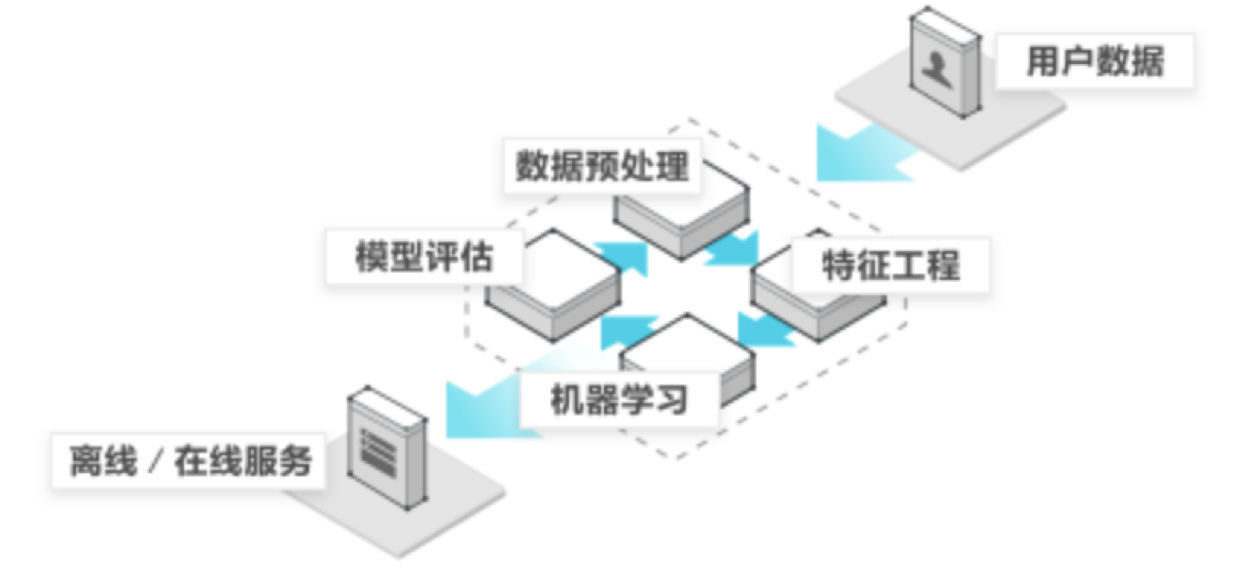
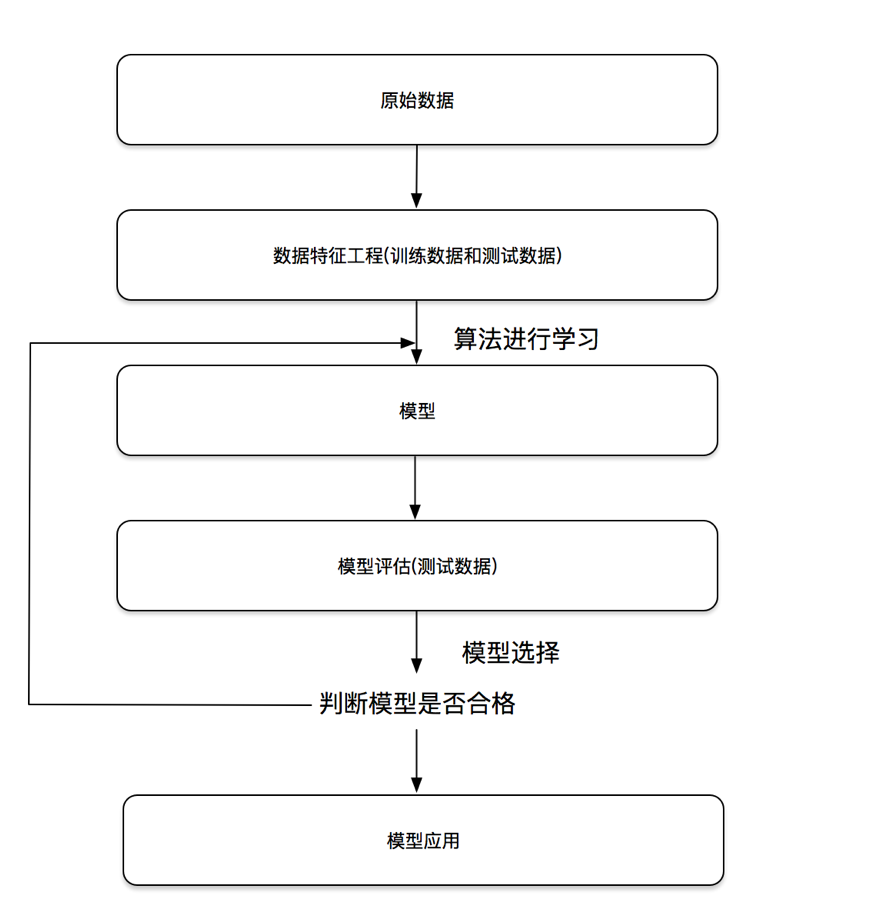


## 1. 数据获取与准备  
数据是机器学习的基础，需确保数据的质量与代表性。  

### 关键任务  
- **数据来源**：  
  - 公开数据集（如Kaggle、UCI、政府开放数据）  
  - 企业数据库（MySQL、Hive表）  
  - 实时采集（API、传感器、日志文件）  

- **数据划分**：  
  - 训练集（70%）、验证集（15%）、测试集（15%）  
  - 时间序列数据需按时间切分，避免未来信息泄露。  

### 注意事项  
- 数据标签的准确性（如人工标注需多轮校验）  
- 数据隐私与合规性（如GDPR、脱敏处理）  


## 2. 数据处理与清洗  
原始数据需清洗和转换以适配模型输入。  

### 核心操作  
| 问题类型   | 处理方法                                         | 工具示例                |  
|------------|--------------------------------------------------|-------------------------|  
| 缺失值     | 删除样本、均值/中位数填充、插值法、模型预测填充（如KNN） | Pandas, Scikit-learn    |  
| 异常值     | 标准差法（3σ原则）、IQR（箱线图）、聚类检测       | NumPy, Seaborn          |  
| 数据标准化 | Z-Score标准化、Min-Max归一化                     | Scikit-learn            |  
| 类别不平衡 | 过采样（SMOTE）、欠采样、调整类别权重（如class_weight参数） | Imbalanced-learn        |  

### 关键点  
- 文本数据需处理编码问题（如UTF-8）和特殊符号。  
- 图像数据需统一尺寸、归一化像素值（0~1）。  


## 3. 特征工程  
特征工程是提升模型性能的核心，目标是构建信息丰富且无冗余的特征。  

### 核心步骤  
1. **特征构造**：  
   - 数值特征：分箱（Binning）、多项式变换（如平方、交叉项）  
   - 时间特征：提取年、月、日、小时、是否为节假日  
   - 文本特征：TF-IDF、词向量（Word2Vec）  

2. **特征选择**：  
   - 过滤法（方差阈值、卡方检验）  
   - 包裹法（递归特征消除RFE）  
   - 嵌入法（L1正则化、树模型特征重要性）  

3. **降维**：  
   - 线性方法：PCA（主成分分析）  
   - 非线性方法：t-SNE、UMAP  

### 工具推荐  
- 特征构造：Pandas, Feature-engine  
- 特征选择：Scikit-learn, XGBoost  
- 降维：Scikit-learn, OpenTSNE  


## 4. 模型训练与调优  
根据任务类型选择算法，并通过实验找到最优超参数。  

### 常用算法对照表  
| 任务类型   | 算法示例                                  | 适用场景                                  |  
|------------|-------------------------------------------|-------------------------------------------|  
| 分类       | 逻辑回归、随机森林、SVM、XGBoost、BERT（文本分类） | 信用评分、图像分类、情感分析              |  
| 回归       | 线性回归、决策树回归、LightGBM、Prophet（时间序列） | 房价预测、销量预测                        |  
| 聚类       | K-Means、DBSCAN、层次聚类                 | 用户分群、异常检测                        |  
| 推荐系统   | 协同过滤、矩阵分解（MF）、深度推荐模型（Wide & Deep） | 电商商品推荐、视频内容推荐                |  

### 调优方法  
- **网格搜索（Grid Search）**：遍历所有参数组合，适合小参数空间。  
- **随机搜索（Random Search）**：高效探索大参数空间。  
- **贝叶斯优化（Bayesian Optimization）**：基于概率模型选择最优参数。  

### 代码示例（Scikit-learn）  
```python  
from sklearn.model_selection import GridSearchCV  
params = {'n_estimators': [50, 100], 'max_depth': [3, 5]}  
grid = GridSearchCV(RandomForestClassifier(), params, cv=5)  
grid.fit(X_train, y_train)  
print("最优参数：", grid.best_params_)  
```  


## 5. 模型评估与验证  
需使用独立测试集验证模型泛化性能，避免过拟合。  

### 评估指标对照表  
| 任务类型   | 常用指标                                  | 公式/说明                                  |  
|------------|-------------------------------------------|-------------------------------------------|  
| 分类       | 准确率（Accuracy）、F1-Score、AUC-ROC     | F1 = 2*(Precision*Recall)/(Precision+Recall) |  
| 回归       | MAE（平均绝对误差）、RMSE（均方根误差）   | RMSE = √(Σ(y_pred - y_true)²/N)           |  
| 聚类       | 轮廓系数（Silhouette Score）、Calinski-Harabasz指数 | 衡量簇内紧密度和簇间分离度                |  
| 目标检测   | mAP（平均精度均值）、IoU（交并比）        | 多类别检测任务常用指标                    |  

### 验证策略  
- 交叉验证：K-Fold（K=5或10）、时间序列交叉验证。  
- 业务验证：如推荐系统的A/B测试，对比新旧模型转化率。  


## 6. 模型部署与监控  
模型需通过工程化部署实现商业价值。  

### 部署方式对比  
| 部署形式   | 适用场景                                  | 工具/框架                                  |  
|------------|-------------------------------------------|-------------------------------------------|  
| REST API   | 微服务架构，实时推理                      | Flask, FastAPI, TensorFlow Serving        |  
| 嵌入式部署 | 端侧设备（手机、IoT）                     | TensorFlow Lite, ONNX Runtime             |  
| 批处理任务 | 离线数据预测                              | Apache Airflow, Spark ML                  |  
| 云服务     | 快速扩展的SaaS应用                        | AWS SageMaker, Azure ML                   |  

### 监控与维护  
- 性能监控：推理延迟、吞吐量、CPU/内存占用。  
- 数据漂移检测：监控特征分布变化（如KS检验）。  
- 模型再训练：定期全量训练或在线学习（Online Learning）。  


## 全流程总结表格  
| 阶段         | 核心任务                                  | 常用工具/方法                              | 注意事项                                  |  
|--------------|-------------------------------------------|-------------------------------------------|-------------------------------------------|  
| 数据获取     | 收集、划分数据集                          | Pandas, SQL, Kaggle                       | 确保数据隐私与合规性                      |  
| 数据处理     | 清洗缺失值、异常值，标准化数据            | Scikit-learn, Imbalanced-learn            | 避免测试集信息泄露到训练集                |  
| 特征工程     | 构造、选择、降维特征                      | PCA, Feature-engine, XGBoost              | 结合业务理解设计特征                      |  
| 模型训练     | 算法选型、超参数调优                      | Scikit-learn, LightGBM, AutoML            | 优先选择简单可解释的模型                  |  
| 模型评估     | 验证泛化能力，对比业务指标                | Matplotlib, SHAP, MLflow                  | 避免过拟合，关注负样本表现                |  
| 部署与监控   | 发布API、监控性能、定期迭代                | Docker, Prometheus, Grafana               | 记录模型版本和预测日志                    |  


## 结语  

机器学习项目的成功依赖端到端的流程把控与持续迭代优化。开发者需牢记：  

- **数据质量 > 算法复杂度**：90%的模型问题源于数据缺陷。  
- **模型服务于业务**：评估指标需与商业目标对齐（如ROI、用户留存）。  
- **工程化是关键**：从Jupyter Notebook到生产环境需严谨的代码封装和测试。  

通过系统化的流程设计和工具链支撑，机器学习项目才能真正从实验走向落地，创造商业价值。